In [1]:
# ============================================================
# Section 1: Setup & Imports
# ============================================================

# Standard data manipulation and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:

# Section 1.2: Load the Data

# Load training and test datasets
train = pd.read_csv('fraudTrain.csv')
test  = pd.read_csv('fraudTest.csv')

# Quick sanity check
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print()
print(train.head(3))

Train shape: (1296675, 23)
Test shape:  (555719, 23)

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   

                          merchant       category     amt      first     last  \
0       fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer    Banks   
1  fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie     Gill   
2             fraud_Lind-Buckridge  entertainment  220.11     Edward  Sanchez   

  gender                        street  ...      lat      long  city_pop  \
0      F                561 Perry Cove  ...  36.0788  -81.1781      3495   
1      F  43039 Riley Greens Suite 393  ...  48.8878 -118.2105       149   
2      M      594 White Dale Suite 530  ...  42.1808 -112.2620      4154   

                                 job         dob  \
0          Psychologist, counsellin

In [3]:
# ============================================================
# Section 2: Exploratory Data Analysis (EDA)
# ============================================================

# --- 2.1 Basic Info ---
print("=== TRAINING DATA INFO ===")
print(train.info())
print()
print("=== MISSING VALUES ===")
print(train.isnull().sum())

=== TRAINING DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  floa

Transaction counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentages:
is_fraud
0    99.42
1     0.58
Name: proportion, dtype: float64


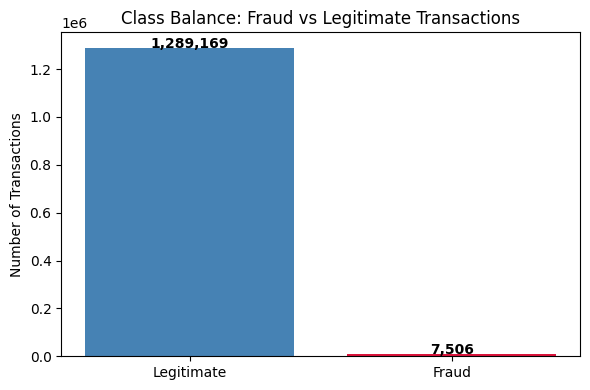

In [4]:
# --- 2.2 Class Balance ---
# Check how many fraud vs legitimate transactions exist
fraud_counts = train['is_fraud'].value_counts()
fraud_pct = train['is_fraud'].value_counts(normalize=True) * 100

print("Transaction counts:")
print(fraud_counts)
print()
print("Percentages:")
print(fraud_pct.round(2))

# Plot class balance
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class Balance: Fraud vs Legitimate Transactions')
ax.set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150)
plt.show()

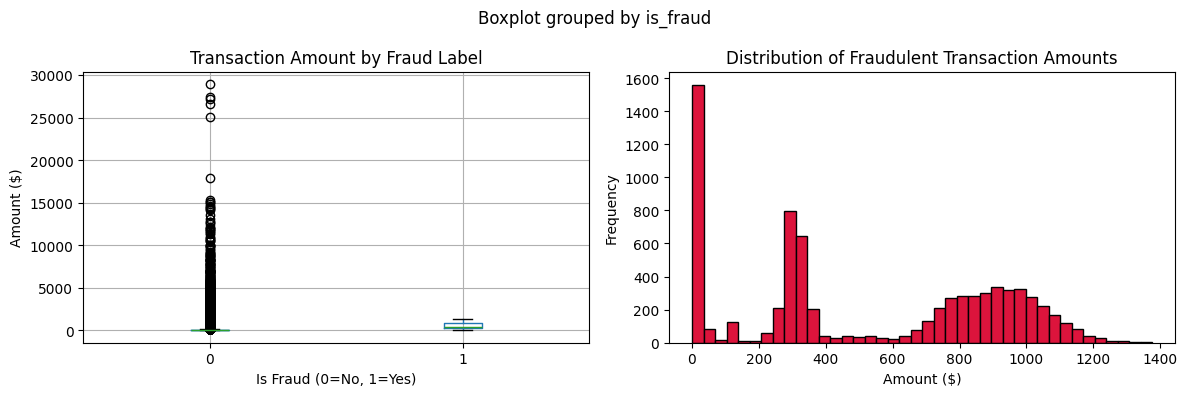

Average legitimate transaction: $ 67.67
Average fraudulent transaction: $ 531.32


In [5]:
# --- 2.3 Transaction Amount: Fraud vs Legitimate ---
# Compare how much money is involved in fraud vs normal transactions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
train.boxplot(column='amt', by='is_fraud', ax=axes[0])
axes[0].set_title('Transaction Amount by Fraud Label')
axes[0].set_xlabel('Is Fraud (0=No, 1=Yes)')
axes[0].set_ylabel('Amount ($)')

# Distribution for fraud only (capped at $1500 for readability)
fraud_only = train[train['is_fraud'] == 1]
axes[1].hist(fraud_only['amt'], bins=40, color='crimson', edgecolor='black')
axes[1].set_title('Distribution of Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

print("Average legitimate transaction: $", round(train[train['is_fraud']==0]['amt'].mean(), 2))
print("Average fraudulent transaction: $", round(train[train['is_fraud']==1]['amt'].mean(), 2))

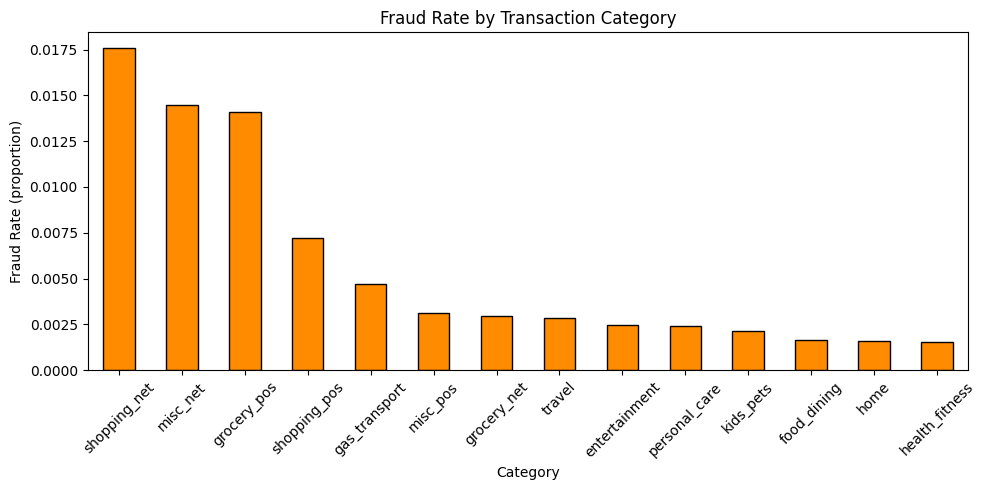

In [6]:
# --- 2.4 Fraud Rate by Transaction Category ---
category_fraud = train.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
category_fraud.plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Fraud Rate by Transaction Category')
ax.set_ylabel('Fraud Rate (proportion)')
ax.set_xlabel('Category')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fraud_by_category.png', dpi=150)
plt.show()

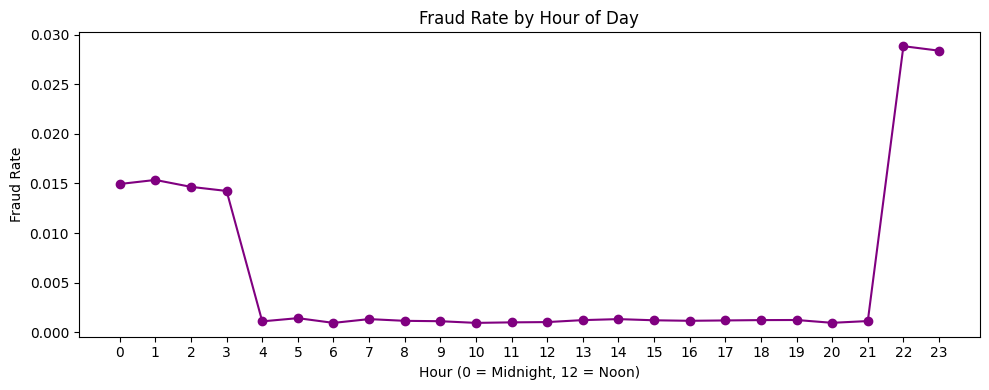

In [7]:
# --- 2.5 Fraud by Hour of Day ---
# Extract hour from transaction timestamp
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
train['hour'] = train['trans_date_trans_time'].dt.hour

hourly_fraud = train.groupby('hour')['is_fraud'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_fraud.plot(kind='line', ax=ax, marker='o', color='purple')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xlabel('Hour (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Fraud Rate')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150)
plt.show()

In [8]:
# --- 2.6 Fraud by Gender ---
gender_fraud = train.groupby('gender')['is_fraud'].mean()
print("Fraud rate by gender:")
print(gender_fraud)

Fraud rate by gender:
gender
F    0.005262
M    0.006426
Name: is_fraud, dtype: float64


In [9]:
# ============================================================
# Section 3: Data Cleaning & Preprocessing
# ============================================================

# --- 3.1 Drop Unnecessary Columns ---
# These columns are identifiers or free text that won't help the model:
# - 'Unnamed: 0' : just a row index
# - 'trans_num'  : unique transaction ID (not predictive)
# - 'first', 'last', 'street' : personal identifiers, not patterns
# - 'cc_num'     : card number itself isn't predictive without aggregation

cols_to_drop = ['Unnamed: 0', 'trans_num', 'first', 'last', 'street', 'cc_num']

train_clean = train.drop(columns=cols_to_drop)
test_clean  = test.drop(columns=cols_to_drop)

print("Columns after dropping:", list(train_clean.columns))

Columns after dropping: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'hour']


In [10]:
# --- 3.2 Parse Datetime Columns ---
# Convert transaction timestamp and date of birth to datetime format
# so we can extract useful numeric features from them

train_clean['trans_date_trans_time'] = pd.to_datetime(train_clean['trans_date_trans_time'])
test_clean['trans_date_trans_time']  = pd.to_datetime(test_clean['trans_date_trans_time'])

train_clean['dob'] = pd.to_datetime(train_clean['dob'])
test_clean['dob']  = pd.to_datetime(test_clean['dob'])

print("Datetime columns parsed successfully")

Datetime columns parsed successfully


In [11]:
# --- 3.3 Feature Engineering from Datetime ---
# Extract meaningful numeric signals from the timestamps

for df in [train_clean, test_clean]:
    # Hour of transaction (fraud may cluster at night)
    df['hour'] = df['trans_date_trans_time'].dt.hour

    # Day of week (0=Monday, 6=Sunday)
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

    # Age of cardholder at time of transaction
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

    # Distance between cardholder location and merchant location
    # Using simple Euclidean distance on lat/long as an approximation
    df['distance'] = (
        (df['lat'] - df['merch_lat'])**2 +
        (df['long'] - df['merch_long'])**2
    ) ** 0.5

print("New features created: hour, day_of_week, age, distance")
print(train_clean[['hour', 'day_of_week', 'age', 'distance']].describe().round(2))

New features created: hour, day_of_week, age, distance
             hour  day_of_week         age    distance
count  1296675.00   1296675.00  1296675.00  1296675.00
mean        12.80         3.07       45.53        0.77
std          6.82         2.20       17.41        0.28
min          0.00         0.00       13.00        0.00
25%          7.00         1.00       32.00        0.56
50%         14.00         3.00       44.00        0.80
75%         19.00         5.00       57.00        0.98
max         23.00         6.00       95.00        1.41


In [12]:
# --- 3.4 Drop Original Datetime & Location Columns ---
# Now that we've extracted what we need, drop the raw versions
# The model needs numbers, not datetime objects or raw coordinates

raw_cols = ['trans_date_trans_time', 'dob', 'lat', 'long',
            'merch_lat', 'merch_long', 'zip', 'unix_time']

train_clean = train_clean.drop(columns=raw_cols)
test_clean  = test_clean.drop(columns=raw_cols)

print("Remaining columns:", list(train_clean.columns))

Remaining columns: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop', 'job', 'is_fraud', 'hour', 'day_of_week', 'age', 'distance']


In [13]:
# --- 3.5 Encode Categorical Variables ---
# Machine learning models need numbers, not text.
# We use Label Encoding to convert each category to an integer.
# Columns to encode: merchant, category, gender, city, state, job

from sklearn.preprocessing import LabelEncoder

categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']

le = LabelEncoder()

for col in categorical_cols:
    # Fit on combined train+test to avoid unseen label errors
    combined = pd.concat([train_clean[col], test_clean[col]], axis=0).astype(str)
    le.fit(combined)
    train_clean[col] = le.transform(train_clean[col].astype(str))
    test_clean[col]  = le.transform(test_clean[col].astype(str))

print("Categorical encoding complete")
print(train_clean.head(3))

Categorical encoding complete
   merchant  category     amt  gender  city  state  city_pop  job  is_fraud  \
0       514         8    4.97       0   532     27      3495  372         0   
1       241         4  107.23       0   619     47       149  431         0   
2       390         0  220.11       1   474     13      4154  308         0   

   hour  day_of_week  age  distance  
0     0            1   30  0.872830  
1     0            1   40  0.272310  
2     0            1   56  0.975845  


In [14]:
# --- 3.6 Separate Features and Target Variable ---
# X = input features the model learns from
# y = what we're trying to predict (is_fraud)

X_train = train_clean.drop(columns=['is_fraud'])
y_train = train_clean['is_fraud']

X_test  = test_clean.drop(columns=['is_fraud'])
y_test  = test_clean['is_fraud']

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Fraud cases in train:", y_train.sum())
print("Fraud cases in test: ", y_test.sum())

X_train shape: (1296675, 12)
X_test shape:  (555719, 12)
Fraud cases in train: 7506
Fraud cases in test:  2145


In [15]:
# --- 3.7 Handle Class Imbalance with Class Weights ---
# Since only ~0.58% of transactions are fraud, a naive model would just
# predict "not fraud" every time and still get 99% accuracy.
# Class weights force the model to penalise missing fraud cases more heavily.

from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight='balanced',
                                classes=np.array([0, 1]),
                                y=y_train)

class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)
# The fraud class (1) will have a much higher weight than legitimate (0)

Class weights: {0: np.float64(0.5029111776656126), 1: np.float64(86.37589928057554)}


In [ ]:
# ============================================================
# Section 4: Model Training & Evaluation
# ============================================================

# --- 4.1 Train Logistic Regression (Baseline Model) ---
# Logistic Regression is a simple, interpretable baseline model.
# We use it first to establish a performance benchmark.
# class_weight='balanced' handles the fraud/non-fraud imbalance.
# max_iter=1000 ensures the model has enough steps to converge.

from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression... (this may take 1-2 minutes)")

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Logistic Regression training complete!")

Training Logistic Regression... (this may take 1-2 minutes)


In [ ]:
# --- 4.2 Evaluate Logistic Regression ---
# Predict on the test set
lr_preds  = lr_model.predict(X_test)
lr_probs  = lr_model.predict_proba(X_test)[:, 1]  # probability of fraud

print("=== LOGISTIC REGRESSION RESULTS ===")
print()
# Classification report shows precision, recall and F1 for each class
# Focus on the fraud class (label 1) — that's what matters here
print(classification_report(y_test, lr_preds,
                             target_names=['Legitimate', 'Fraud']))

print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_probs), 4))

In [ ]:
# --- 4.3 Train Random Forest Model ---
# Random Forest is an ensemble of decision trees.
# It handles non-linear relationships and is well-suited to tabular data.
# n_estimators=100 = number of trees (good balance of speed vs accuracy)
# class_weight='balanced' again handles the imbalance
# n_jobs=-1 uses all CPU cores to speed up training

print("Training Random Forest... (this may take 3-5 minutes in Colab)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete!")

In [ ]:
# --- 4.4 Evaluate Random Forest ---
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST RESULTS ===")
print()
print(classification_report(y_test, rf_preds,
                             target_names=['Legitimate', 'Fraud']))

print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_probs), 4))

In [ ]:
# --- 4.5 Confusion Matrices (side by side) ---
# A confusion matrix shows us exactly where each model goes wrong:
# - True Positives  (fraud correctly caught)
# - False Positives (legitimate flagged as fraud)
# - False Negatives (fraud that slipped through — most costly!)
# - True Negatives  (legitimate correctly cleared)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {title}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
# --- 4.6 ROC Curves (both models on same chart) ---
# The ROC curve shows the trade-off between catching fraud (recall)
# and falsely flagging legitimate transactions (false positive rate).
# A higher AUC (area under curve) = better overall model.

fig, ax = plt.subplots(figsize=(7, 5))

for probs, label, color in zip(
        [lr_probs, rf_probs],
        ['Logistic Regression', 'Random Forest'],
        ['steelblue', 'crimson']):

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})', color=color)

# Diagonal line = random guessing baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [ ]:
# --- 4.7 Feature Importance (Random Forest) ---
# Random Forest can tell us which features it found most useful
# for distinguishing fraud from legitimate transactions.
# This is valuable for the report's Results section.

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(12).plot(kind='bar', ax=ax,
                           color='darkorange', edgecolor='black')
ax.set_title('Top 12 Most Important Features (Random Forest)')
ax.set_ylabel('Feature Importance Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 5 features:")
print(importances.head(5))

In [ ]:
# --- 4.8 Summary Comparison Table ---
# Bring together the key metrics for both models in one place

from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision (Fraud)': [
        round(precision_score(y_test, lr_preds), 4),
        round(precision_score(y_test, rf_preds), 4)
    ],
    'Recall (Fraud)': [
        round(recall_score(y_test, lr_preds), 4),
        round(recall_score(y_test, rf_preds), 4)
    ],
    'F1 Score (Fraud)': [
        round(f1_score(y_test, lr_preds), 4),
        round(f1_score(y_test, rf_preds), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_probs), 4),
        round(roc_auc_score(y_test, rf_probs), 4)
    ]
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

In [ ]:
# ============================================================
# Section 5: Results Visualisation
# ============================================================

# --- 5.1 Fraud Rate by Transaction Category (Polished) ---
# This chart shows which spending categories carry the highest fraud risk.
# A cleaner version of the EDA chart, suitable for the report.

category_fraud_rate = train.groupby('category')['is_fraud'].mean() * 100
category_fraud_rate = category_fraud_rate.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(category_fraud_rate.index,
               category_fraud_rate.values,
               color='crimson', edgecolor='black', alpha=0.8)

# Add percentage labels on each bar
for bar, val in zip(bars, category_fraud_rate.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Transaction Category', fontsize=13, fontweight='bold')
ax.set_xlim(0, category_fraud_rate.max() * 1.2)
plt.tight_layout()
plt.savefig('fraud_rate_by_category.png', dpi=150)
plt.show()

In [ ]:
# --- 5.2 Fraud Rate by Hour of Day (Polished) ---
# Shows when during the day fraud is most likely to occur.
# Useful for recommending time-based alert thresholds.

hourly = train.groupby('hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(hourly.index, hourly.values,
                color='purple', alpha=0.3)
ax.plot(hourly.index, hourly.values,
        color='purple', marker='o', linewidth=2)

ax.set_xlabel('Hour of Day (0 = Midnight)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.axvspan(0, 5, alpha=0.1, color='red', label='High-risk window (midnight–5am)')
ax.legend()
plt.tight_layout()
plt.savefig('fraud_rate_by_hour.png', dpi=150)
plt.show()

In [ ]:
# --- 5.3 Transaction Amount: Fraud vs Legitimate (Polished) ---
# Overlapping distribution plot showing the clear difference in
# transaction amounts between fraudulent and legitimate transactions.

fig, ax = plt.subplots(figsize=(9, 5))

# Cap at $1500 so the chart is readable (extreme outliers skew the axis)
legitimate = train[train['is_fraud'] == 0]['amt']
fraudulent = train[train['is_fraud'] == 1]['amt']

ax.hist(legitimate[legitimate <= 1500], bins=60,
        alpha=0.5, color='steelblue',
        label=f'Legitimate (n={len(legitimate):,})', density=True)

ax.hist(fraudulent[fraudulent <= 1500], bins=60,
        alpha=0.6, color='crimson',
        label=f'Fraud (n={len(fraudulent):,})', density=True)

ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution: Fraud vs Legitimate',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('amount_comparison.png', dpi=150)
plt.show()

print(f"Median legitimate: ${legitimate.median():.2f}")
print(f"Median fraudulent: ${fraudulent.median():.2f}")

In [ ]:
# --- 5.4 Fraud Rate by Age Group ---
# Shows whether certain age groups are more vulnerable to fraud.
# Age was a feature we engineered ourselves — good to visualise its impact.

train_clean_plot = train.copy()
train_clean_plot['age'] = (
    pd.to_datetime(train_clean_plot['trans_date_trans_time']) -
    pd.to_datetime(train_clean_plot['dob'])
).dt.days // 365

# Bin ages into groups
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
train_clean_plot['age_group'] = pd.cut(
    train_clean_plot['age'], bins=bins, labels=labels
)

age_fraud = train_clean_plot.groupby('age_group')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
age_fraud.plot(kind='bar', ax=ax,
               color='teal', edgecolor='black', alpha=0.8)
ax.set_title('Fraud Rate by Cardholder Age Group',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Fraud Rate (%)')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(age_fraud.values):
    ax.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fraud_by_age.png', dpi=150)
plt.show()

In [ ]:
# --- 5.5 Model Comparison Bar Chart ---
# A clean visual summary of both models across all four metrics.
# This is the chart most likely to go into your report's Results section.

metrics = ['Precision (Fraud)', 'Recall (Fraud)', 'F1 Score (Fraud)', 'ROC-AUC']

# !! Replace these values with YOUR actual results from Section 4 !!
lr_scores = [
    precision_score(y_test, lr_preds),
    recall_score(y_test, lr_preds),
    f1_score(y_test, lr_preds),
    roc_auc_score(y_test, lr_probs)
]

rf_scores = [
    precision_score(y_test, rf_preds),
    recall_score(y_test, rf_preds),
    f1_score(y_test, rf_preds),
    roc_auc_score(y_test, rf_probs)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_scores, width,
               label='Logistic Regression',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_scores, width,
               label='Random Forest',
               color='crimson', edgecolor='black')

# Add value labels on top of each bar
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
# --- 5.6 Save All Results to a Summary CSV ---
# Useful to reference exact numbers when writing the report

results.to_csv('model_results_summary.csv', index=False)
print("All results saved!")
print()
print("Charts saved:")
charts = [
    'class_balance.png',
    'amount_distribution.png',
    'fraud_by_category.png',
    'fraud_rate_by_category.png',
    'fraud_rate_by_hour.png',
    'amount_comparison.png',
    'fraud_by_age.png',
    'confusion_matrices.png',
    'roc_curves.png',
    'feature_importance.png',
    'model_comparison.png'
]
for c in charts:
    print(f"  ✓ {c}")